### Plot ggplot version of the senescence results

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
plots_dir <- "senescence_plots/"
dir.create(plots_dir)

Warning message in dir.create(plots_dir):
“'senescence_plots' already exists”


In [3]:
senescence_results_df <- read.csv("01_senescence_results.csv")
senescence_results_df$X <- NULL

In [4]:
#senescence_results_df

In [5]:
# add significance column
senescence_results_df$significant <- FALSE
p_val_threshold <- 0.05
senescence_results_df[senescence_results_df$adjusted_p_val < p_val_threshold, 'significant'] <- TRUE

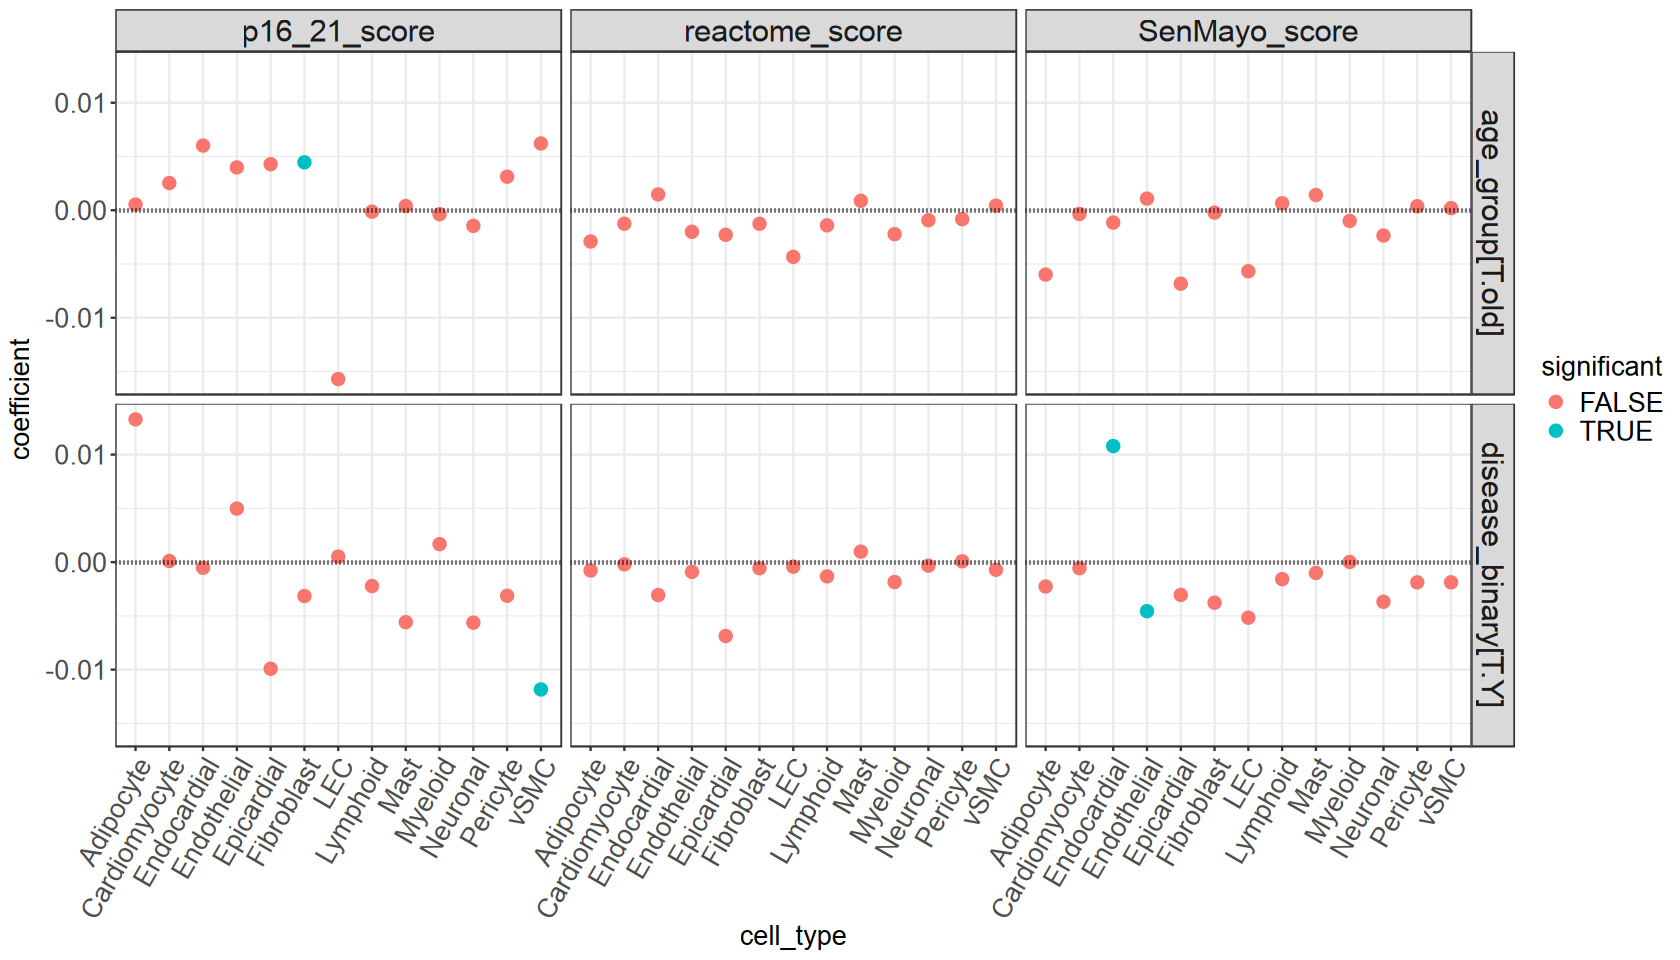

In [9]:
options(repr.plot.width = 14, repr.plot.height = 8)

senescence_plot <- ggplot(data = senescence_results_df, mapping = aes(x = cell_type, y = coefficient, color = significant)) + 
geom_point(size = 3) + 
facet_grid(contrast ~ score_type) + theme_bw() +
geom_hline(yintercept = 0, linetype = "dotted", color = "black", linewidth = 1) +
theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16), 
         plot.title = element_text(size = 24, hjust = 0.5), 
         axis.title.x = element_text(size = 16),
         axis.title.y = element_text(size = 16),
         axis.text.x = element_text(size = 16, angle = 60, hjust=1),
         axis.text.y = element_text(size = 16),
	 strip.text = element_text(size = 18))

senescence_plot

# save the plot
ggsave(plot = senescence_plot, filename = paste0(plots_dir, "snRNA_senescence_results.pdf"), width = 14, height = 8)